In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

def plot_distance_distributions(dimensions, n_points=1000, bins=50, random_seed=42):
    """
    Генерирует равномерные данные в гиперкубе [0,1]^d 
    и строит гистограммы попарных евклидовых расстояний

    Parameters:
    -----------
    dimensions : list
        Список размерностей для анализа (например, [1, 2, 3,给孩子, 10, 30])
    n_points : int
        Количество генерируемых точек
    bins : int
        Количество бинов для гистограмм
    random_seed : int
        Seed для воспроизводимости
    """
    np.random.seed(random_seed)

    # Рассчитываем количество строк и столбцов для subplots
    n_dims = len(dimensions)
    n_cols = min(3, n_dims)
    n_rows = (n_dims + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_dims > 1 else [axes]

    # Цветовая карта для разных размерностей
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_dims))

    for idx, dim in enumerate(dimensions):
        ax = axes[idx]

        # 1. Генерация равномерно распределенных данных
        data = np.random.uniform(0, 1, size=(n_points, dim))

        # 2. Вычисление всех попарных евклидовых расстояний
        distances = pdist(data, 'euclidean')

        # 3. Построение гистограммы
        n, bins, patches = ax.hist(distances, bins=bins, density=True, 
                                  alpha=0.7, color=colors[idx], edgecolor='black')

        # Статистики
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        median_dist = np.median(distances)

        # Теоретическое ожидание для равномерного распределения в гиперкубе
        # Для евклидова расстояния в d-мерном гиперкубе [0,1]^d
        # Приближенная формула: sqrt(d/6) для среднего расстояния между случайными точками
        theoretical_mean = np.sqrt(dim/6)

        # Добавляем линии статистик
        ax.axvline(mean_dist, color='red', linestyle='--', linewidth=2, 
                  label=f'Среднее = {mean_dist:.3f}')
        ax.axvline(theoretical_mean, color='green', linestyle=':', linewidth=2,
                  label=f'Теор. среднее ≈ {theoretical_mean:.3f}')

        # Настройки графика
        ax.set_title(f'Размерность d = {dim}\n({n_points} точек, {len(distances):,} попарных расстояний)',
                    fontsize=11, pad=10)
        ax.set_xlabel('Евклидово расстояние', fontsize=10)
        ax.set_ylabel('Плотность вероятности', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)

        # Информация в текстовом блоке
        info_text = (f'Min: {np.min(distances):.3f}\n'
                    f'Max: {np.max(distances):.3f}\n'
                    f'Std: {std_dist:.3f}\n'
                    f'CV: {(std_dist/mean_dist)*100:.1f}%')

        # Добавляем текстовый блок с информацией
        ax.text(0.98, 0.98, info_text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top',
               horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        # Устанавливаем пределы по x для лучшей сравнимости
        max_possible_dist = np.sqrt(dim)  # Максимальное расстояние в гиперкубе [0,1]^d
        ax.set_xlim([0, max_possible_dist * 1.05])

    # Скрываем лишние subplots
    for idx in range(n_dims, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Распределение попарных евклидовых расстояний в гиперкубе [0,1]$^d$\n'
                f'Заметка: CV = коэффициент вариации (std/mean)', 
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Дополнительно: сводная таблица статистик
    print("\n" + "="*80)
    print("СВОДНАЯ ТАБЛИЦА СТАТИСТИК РАССТОЯНИЙ")
    print("="*80)
    print(f"{'Размерность':<12} {'Среднее':<10} {'Теор. среднее':<15} {'Std':<10} {'CV (%)':<10} {'Min':<10} {'Max':<10}")
    print("-"*80)

    stats_summary = []
    for idx, dim in enumerate(dimensions):
        np.random.seed(random_seed + idx)  # Новый seed для каждого измерения
        data = np.random.uniform(0, 1, size=(n_points, dim))
        distances = pdist(data, 'euclidean')

        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        cv = (std_dist/mean_dist)*100
        theoretical_mean = np.sqrt(dim/6)

        stats_summary.append({
            'dim': dim,
            'mean': mean_dist,
            'theoretical': theoretical_mean,
            'std': std_dist,
            'cv': cv,
            'min': np.min(distances),
            'max': np.max(distances)
        })

        print(f"{dim:<12d} {mean_dist:<10.4f} {theoretical_mean:<15.4f} "
              f"{std_dist:<10.4f} {cv:<10.1f} "
              f"{np.min(distances):<10.4f} {np.max(distances):<10.4f}")

    return stats_summary

# Функция для демонстрации тренда коэффициента вариации
def plot_cv_trend(max_dim=50, n_points=500, random_seed=42):
    """Показывает как меняется относительная вариативность расстояний с ростом размерности"""
    np.random.seed(random_seed)

    dims = np.arange(1, max_dim+1)
    cvs = []
    means = []
    stds = []

    for dim in dims:
        data = np.random.uniform(0, 1, size=(n_points, dim))
        distances = pdist(data, 'euclidean')

        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        cv = (std_dist/mean_dist)*100

        means.append(mean_dist)
        stds.append(std_dist)
        cvs.append(cv)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График 1: Среднее расстояние и стандартное отклонение
    ax1.plot(dims, means, 'b-', linewidth=2, label='Среднее расстояние')
    ax1.plot(dims, stds, 'r--', linewidth=2, label='Стандартное отклонение')
    ax1.set_xlabel('Размерность (d)', fontsize=12)
    ax1.set_ylabel('Расстояние', fontsize=12)
    ax1.set_title('Абсолютные значения расстояний', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)

    # Добавляем теоретическую кривую для среднего
    theoretical_means = np.sqrt(dims/6)
    ax1.plot(dims, theoretical_means, 'g:', linewidth=2, label='Теор. среднее √(d/6)')

    # График 2: Коэффициент вариации (в процентах)
    ax2.plot(dims, cvs, 'purple', linewidth=3)
    ax2.set_xlabel('Размерность (d)', fontsize=12)
    ax2.set_ylabel('Коэффициент вариации (%)', fontsize=12)
    ax2.set_title('Относительная вариативность расстояний (CV = std/mean)', fontsize=14)
    ax2.grid(True, alpha=0.3)

    # Добавляем горизонтальную линию для 20%
    ax2.axhline(y=20, color='red', linestyle='--', alpha=0.7, 
               label='CV = 20% (низкая вариативность)')

    # Область где CV становится маленьким
    threshold_idx = np.where(np.array(cvs) < 20)[0]
    if len(threshold_idx) > 0:
        threshold_dim = dims[threshold_idx[0]]
        ax2.axvline(x=threshold_dim, color='orange', linestyle=':', 
                   label=f'd ≈ {threshold_dim} (CV < 20%)')

    ax2.legend(fontsize=11)

    plt.suptitle(f'Эволюция распределения расстояний с ростом размерности\n'
                f'({n_points} точек в гиперкубе [0,1]$^d$)', fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"\nКлючевые наблюдения:")
    print(f"1. Среднее расстояние растет как √d")
    print(f"2. Абсолютное std тоже растет, но медленнее")
    print(f"3. ОТНОСИТЕЛЬНАЯ вариативность (CV) падает!")
    print(f"4. При d > ~{threshold_dim if 'threshold_dim' in locals() else '20'} все расстояния становятся 'похожими'")


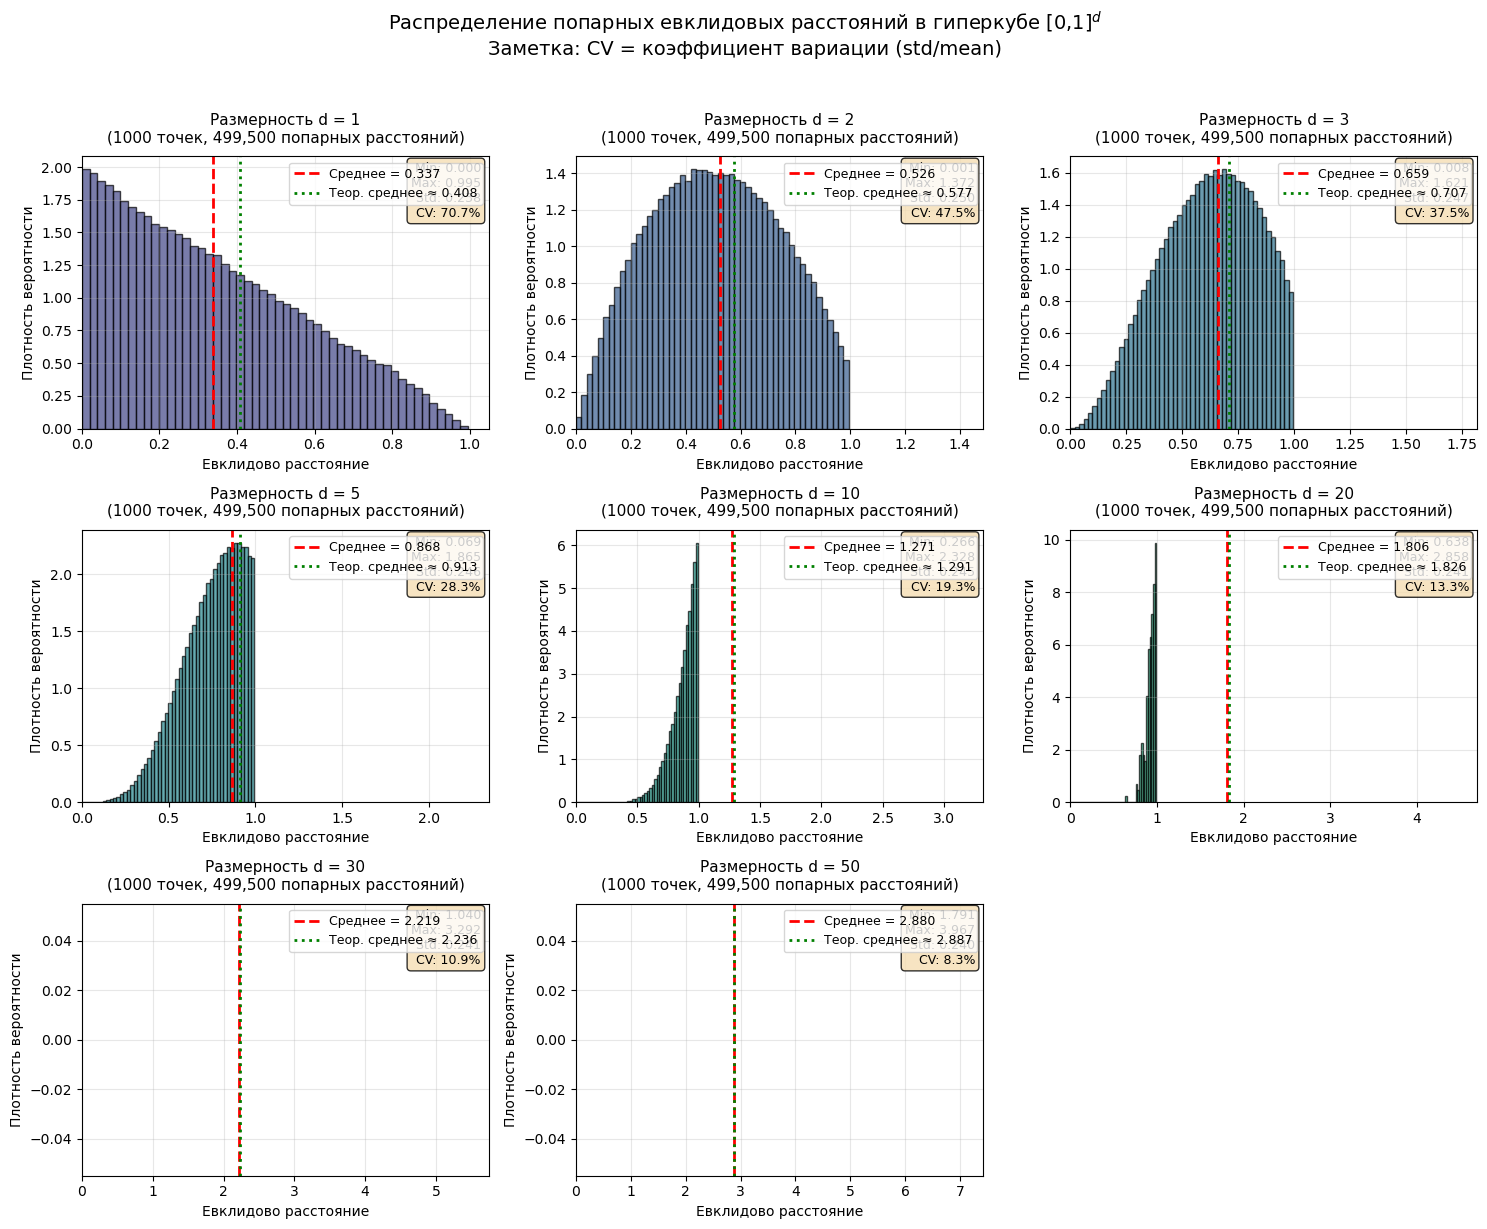


СВОДНАЯ ТАБЛИЦА СТАТИСТИК РАССТОЯНИЙ
Размерность  Среднее    Теор. среднее   Std        CV (%)     Min        Max       
--------------------------------------------------------------------------------
1            0.3374     0.4082          0.2384     70.7       0.0000     0.9951    
2            0.5215     0.5774          0.2471     47.4       0.0011     1.3824    
3            0.6597     0.7071          0.2494     37.8       0.0075     1.6031    
5            0.8757     0.9129          0.2464     28.1       0.0634     1.8445    
10           1.2663     1.2910          0.2444     19.3       0.2702     2.2840    
20           1.8162     1.8257          0.2432     13.4       0.5804     2.8761    
30           2.2236     2.2361          0.2406     10.8       1.0320     3.2774    
50           2.8756     2.8868          0.2422     8.4        1.7603     4.0159    


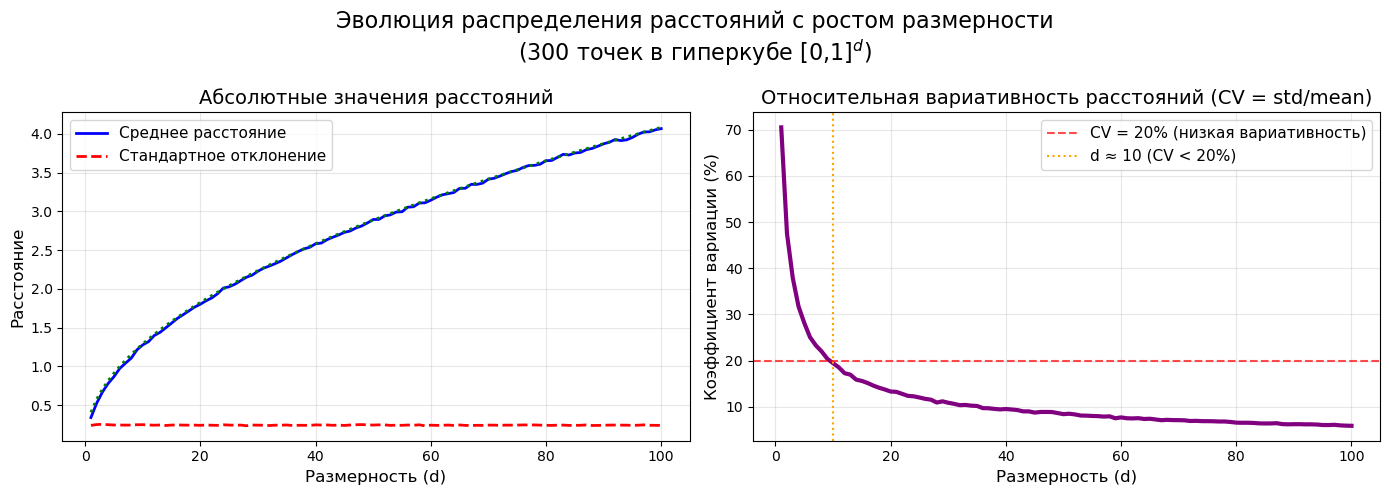


Ключевые наблюдения:
1. Среднее расстояние растет как √d
2. Абсолютное std тоже растет, но медленнее
3. ОТНОСИТЕЛЬНАЯ вариативность (CV) падает!
4. При d > ~10 все расстояния становятся 'похожими'


In [3]:
# Самый показательный диапазон для лекции
stats = plot_distance_distributions(dimensions=[1, 2, 3, 5, 10, 20, 30, 50])

# И тренд для понимания общей картины
plot_cv_trend(max_dim=100, n_points=300)


1
2
3


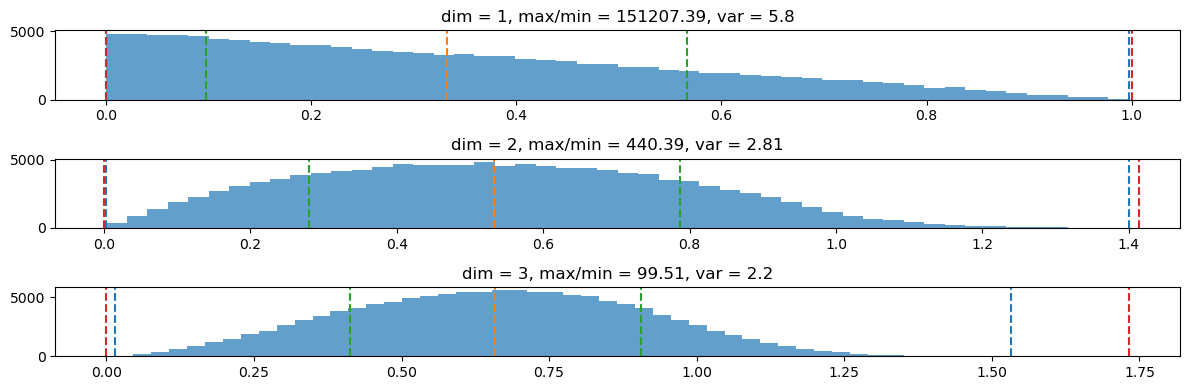

In [106]:
N = 500

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 4), sharex=False, sharey=False)

for d in range(1, 4):
    
    print(d)
    
    dim = d
    points = np.random.rand(N, dim)
    distances = []

    for i in range(N):
        for j in range(i+1, N):
            dist = np.sqrt(np.sum((points[i] - points[j])**2))
            distances.append(dist)
            
    distances_mean = np.array(distances).mean()
    distances_min = np.array(distances).min()
    distances_max = np.array(distances).max()
    distances_std = np.array(distances).std()
    min_max = round(distances_max/distances_min, 2)
    var = round((distances_mean + distances_std) / (distances_mean - distances_std), 2)
    ax[d-1].set_title('dim = '+str(d)+ ', max/min = '+ str(min_max) + ', var = '+ str(var))
#     ax[d-1].grid(True)
    ax[d-1].hist(distances, bins=50, alpha=0.7)
    ax[d-1].axvline(x=distances_mean, color='C1', linestyle='--')
    ax[d-1].axvline(x=distances_mean - distances_std, color='C2', linestyle='--')
    ax[d-1].axvline(x=distances_mean + distances_std, color='C2', linestyle='--')
    ax[d-1].axvline(x=distances_min, color='C0', linestyle='--')
    ax[d-1].axvline(x=distances_max, color='C0', linestyle='--')
    ax[d-1].axvline(x=0, color='C3', linestyle='--')
    ax[d-1].axvline(x=d**0.5, color='C3', linestyle='--')
    
plt.tight_layout()
plt.show()

2
3
4
5
6
7
8
9
10


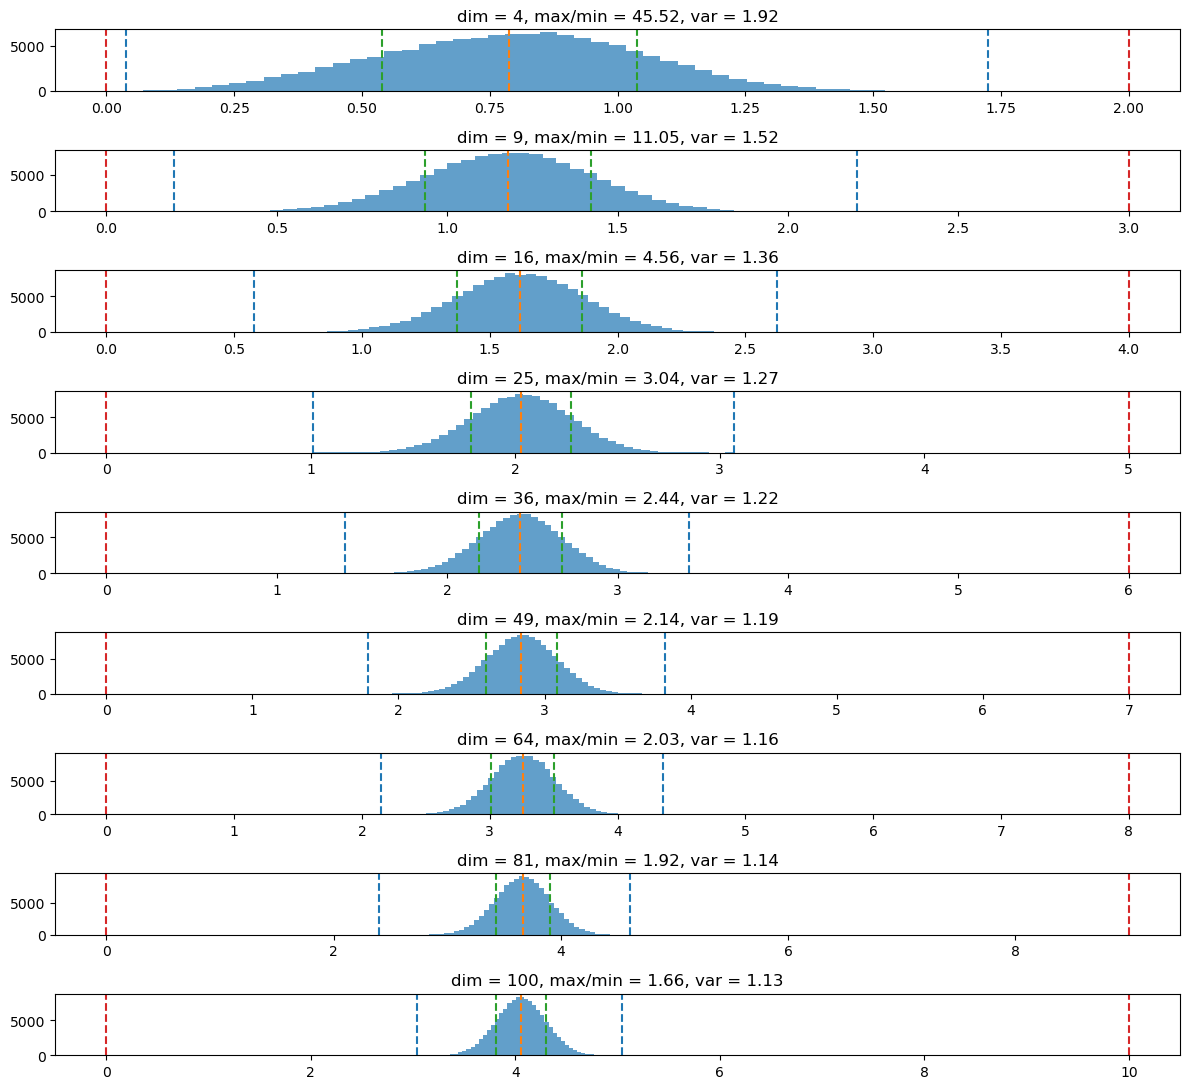

In [107]:
N = 500
k = 11

fig, ax = plt.subplots(nrows=k-2, ncols=1, figsize=(12, k), sharex=False, sharey=False)

for d in range(2, k):
    
    print(d)
    
    dim = d**2
    points = np.random.rand(N, dim)
    distances = []

    for i in range(N):
        for j in range(i+1, N):
            dist = np.sqrt(np.sum((points[i] - points[j])**2))
            distances.append(dist)
            
    distances_mean = np.array(distances).mean()
    distances_min = np.array(distances).min()
    distances_max = np.array(distances).max()
    distances_std = np.array(distances).std()
    min_max = round(distances_max/distances_min, 2)
    var = round((distances_mean + distances_std) / (distances_mean - distances_std), 2)
    ax[d-2].set_title('dim = '+str(d**2)+ ', max/min = '+ str(min_max) + ', var = '+ str(var))
#     ax[d-1].grid(True)
    ax[d-2].hist(distances, bins=50, alpha=0.7)
    ax[d-2].axvline(x=distances_mean, color='C1', linestyle='--')
    ax[d-2].axvline(x=distances_mean - distances_std, color='C2', linestyle='--')
    ax[d-2].axvline(x=distances_mean + distances_std, color='C2', linestyle='--')
    ax[d-2].axvline(x=distances_min, color='C0', linestyle='--')
    ax[d-2].axvline(x=distances_max, color='C0', linestyle='--')
    ax[d-2].axvline(x=0, color='C3', linestyle='--')
    ax[d-2].axvline(x=d, color='C3', linestyle='--')
    
plt.tight_layout()
plt.show()